In [15]:
%pip install pdfplumber

  Using cached pdfplumber-0.11.9-py3-none-any.whl.metadata (43 kB)
  Using cached pdfminer_six-20251230-py3-none-any.whl.metadata (4.3 kB)
  Using cached pypdfium2-5.3.0-py3-none-win_amd64.whl.metadata (67 kB)
  Using cached cryptography-46.0.3-cp311-abi3-win_amd64.whl.metadata (5.7 kB)
Using cached pdfplumber-0.11.9-py3-none-any.whl (60 kB)
Using cached pdfminer_six-20251230-py3-none-any.whl (6.6 MB)
Using cached pypdfium2-5.3.0-py3-none-win_amd64.whl (3.1 MB)
Using cached cryptography-46.0.3-cp311-abi3-win_amd64.whl (3.5 MB)
  Attempting uninstall: cffi
    Found existing installation: cffi 1.17.1
    Uninstalling cffi-1.17.1:
      Successfully uninstalled cffi-1.17.1
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.2 -> 25.3
[notice] To update, run: C:\Users\user\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [3]:
%pip install pdfplumber
import pdfplumber
print(pdfplumber.__version__)

Note: you may need to restart the kernel to use updated packages.
0.11.9



[notice] A new release of pip is available: 24.2 -> 25.3
[notice] To update, run: C:\Users\user\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


### 路徑問題
#### \被視為「跳脫字元」（Escape Character）。例如 \n 代表換行，會被誤判為特殊指令
#### Solution 1 : 前面加r = raw string  告訴 Python：「這裡面的斜線就是斜線，不要當成特殊指令。」
#### Solution 2 : 把 \ 變成 / --> Linux寫法

### <span style="color : #FFF8DE"> 測試1 : 讀取出單頁pdf檔的文字內容+圖片 </span>
### <span style="color : #FFF8DE"> 使用模組 : pdfplumber </span>
### <span style="color : #FFF8DE"> 官方文件 : https://github.com/jsvine/pdfplumber/blob/stable/README.md </span>



考試院考試及格證書
(114)專高會字第000515號
姓 名：林詠翔
性 別：男
國民身分證統一編號： E125984066
出生日期：民國90年10月25日
考試名稱：114年專門職業及技術人員高等考試會計師考試
生效日期：以民國114年10月15日榜示及格之日生效
院 長
典試委員長
考選部部長
中 華 民 國 1 1 5 年 1 月
1
5
3


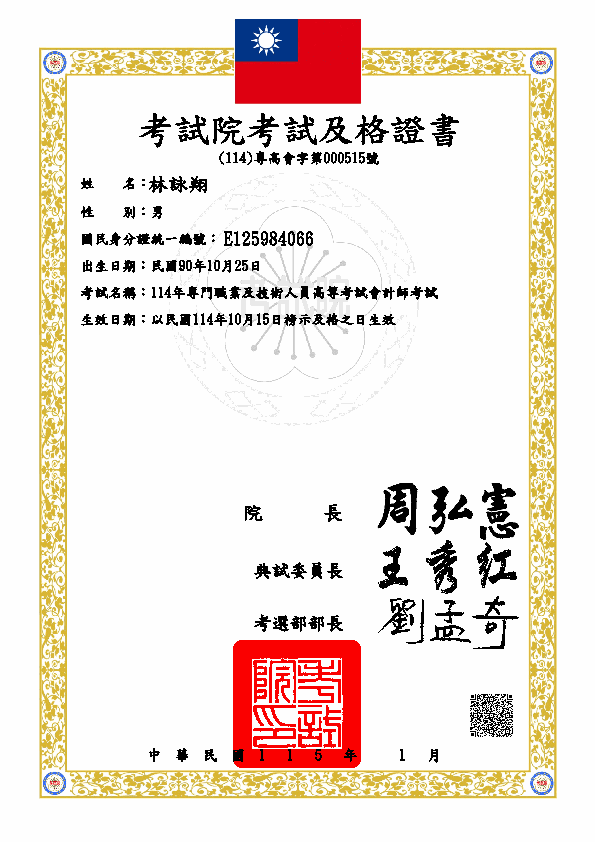

In [5]:
import pandas as pd
pdf = pdfplumber.open(r"C:\Users\user\Documents\實證研究\pdf_crawling\(114)專高會字第515號_unlocked.pdf")
# 讀取第1頁
p0=pdf.pages[0]
im = p0.to_image()
text=p0.extract_text()
im=p0.to_image()
print(text)
E_yuan=text.count("考試院")
exam=text.count("考試")
num=text.count(r"114")
print(E_yuan)
print(exam)
print(num)

#### reset() --> 清除目前為止所繪製的所有內容
#### im.draw_rect(bbox_or_obj, fill={color}, stroke={color}, stroke_width=1) 
#### =  Draws a rectangle from a rect, char, etc., or 4-tuple bounding box.

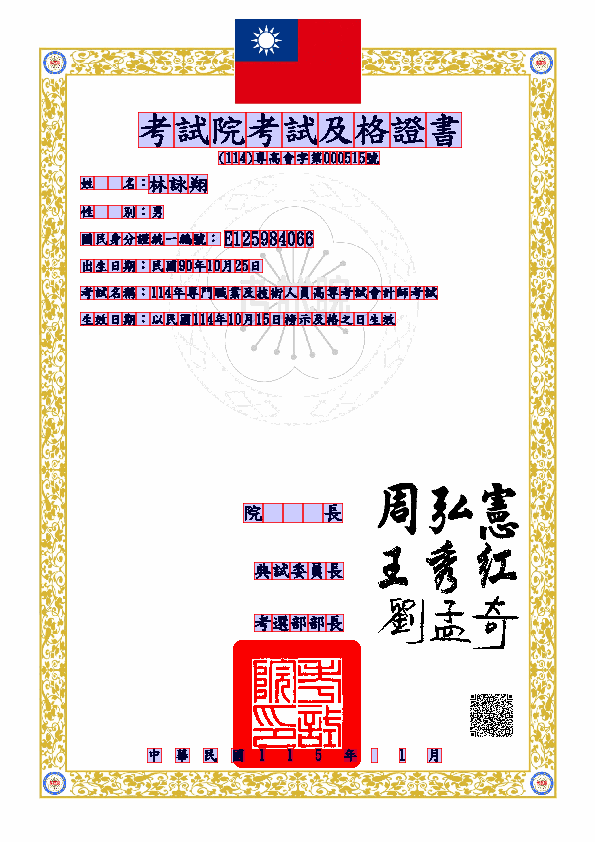

In [7]:
im.reset().draw_rects(p0.chars)

### Gemini範例 : 用迴圈儲存讀取內容到excel
### 發現 : 若非table形式，則所有內容皆會儲存於同個excel儲存格內

In [ ]:
import pdfplumber
import pandas as pd

# 1. 設定檔案路徑 (已加上 r 防止轉義字元錯誤)
pdf_path = r"C:\Users\user\Documents\實證研究\pdf_crawling\(114)專高會字第515號_unlocked.pdf"
output_excel = "報告內容彙整.xlsx"  # 輸出的 Excel 檔名

# 準備一個空的 List 來裝資料
all_data = []

print("開始讀取 PDF...")

try:
    with pdfplumber.open(pdf_path) as pdf:
        total_pages = len(pdf.pages)
        print(f"這份文件共有 {total_pages} 頁")

        # 2. 迴圈遍歷每一頁 enumerate--> (0,data1) (1,data2)
        for i, page in enumerate(pdf.pages):
            # 抓取該頁文字
            text = page.extract_text()
            
            # 如果該頁有文字，就存下來；如果是空白頁則存 "無內容"
            content = text if text else "無內容"
            
            # 把「頁碼」跟「內容」存成一個小清單
            # i + 1 是因為程式是從 0 開始數，但我們習慣看第 1 頁
            all_data.append([i + 1, content])
            
            # 每處理 10 頁印一次進度，讓你知道程式還在跑
            if (i + 1) % 10 == 0:
                print(f"已處理 {i + 1} / {total_pages} 頁...")

    # 3. 將 List 轉換成 Pandas DataFrame
    df = pd.DataFrame(all_data, columns=["頁碼", "內容"])

    # 4. 存成 Excel
    # engine='openpyxl' 是為了確保相容性
    df.to_excel(output_excel, index=False, engine='openpyxl')
    
    print("-" * 30)
    print(f"成功！檔案已儲存為：{output_excel}")
    print("你可以打開 Excel 使用 Ctrl+F 搜尋關鍵字了。")

except FileNotFoundError:
    print("錯誤：找不到檔案，請確認路徑是否正確。")
except Exception as e:
    print(f"發生未預期的錯誤：{e}")

開始讀取 PDF...
這份文件共有 1 頁
------------------------------
成功！檔案已儲存為：報告內容彙整.xlsx
你可以打開 Excel 使用 Ctrl+F 搜尋關鍵字了。


In [10]:
%pip install pypdf
from pypdf import PdfReader

reader = PdfReader("(114)專高會字第515號_unlocked.pdf")

page=reader.pages
for page in reader.pages:
    print(page.extract_text())

Note: you may need to restart the kernel to use updated packages.Requirement already satisfied: pypdf in c:\users\user\appdata\local\packages\pythonsoftwarefoundation.python.3.11_qbz5n2kfra8p0\localcache\local-packages\python311\site-packages (6.6.0)

考試院考試及格證書
(114)專高會字第000515號
姓　　名：林詠翔
性　　別：男
國民身分證統一編號：
出生日期：民國90年10月25日
考試名稱：114年專門職業及技術人員高等考試會計師考試
生效日期：以民國114年10月15日榜示及格之日生效
E125984066
中 華 民 國 1 1 5 年  1 月 
院　　　長
典試委員長
考選部部長



[notice] A new release of pip is available: 24.2 -> 25.3
[notice] To update, run: C:\Users\user\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


### <span style="color : #ec39dd"> 測試2 : 讀取出單頁pdf檔的圖片/掃描內容 </span>
### <span style="color : #ec39dd"> 使用模組 : pytesseract </span>
### 結果 : 解讀結果較pdf檔不精確，雖然能解讀出簽名，但匯出的text為亂碼
### 原因 : 可能是圖片檔架構較pdf檔簡單，判讀精確率相對較低


In [1]:
%pip install pytesseract
import pytesseract
from PIL import Image

pytesseract.pytesseract.tesseract_cmd = r"C:\Program Files\Tesseract-OCR\tesseract.exe"
img = Image.open("image 4 (2).png")
width, height = img.size
new_size = (width * 2, height * 2)
img_resized = img.resize(new_size, Image.Resampling.LANCZOS)

# 轉成灰階 (去除干擾色)
img_gray = img_resized.convert('L')

# 再丟進去辨識
text = pytesseract.image_to_string(img_gray, lang='chi_tra')


# 儲存提取的文字為 .txt 文件
with open("pytesseract_output.txt", "w") as text_file:
    text_file.write(text)


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.2 -> 25.3
[notice] To update, run: C:\Users\user\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [23]:
%pip install chardet
import chardet

file_path = 'pytesseract_output.txt'

# 1. 先用二進位模式 ('rb') 讀取原始資料
with open(file_path, 'rb') as f:
    raw_data = f.read()

# 2. 讓 chardet 偵測編碼
result = chardet.detect(raw_data)
encoding_type = result['encoding']
confidence = result['confidence']

print(f"偵測到的編碼是: {encoding_type} (信心度: {confidence})")

# 3. 用偵測到的編碼重新讀取文字

text = raw_data.decode('cp950')
print("--- 內容如下 ---")
print(text) 


Note: you may need to restart the kernel to use updated packages.
偵測到的編碼是: Big5 (信心度: 0.99)
--- 內容如下 ---
考 試 院 考 試 及 格 證 書
(114﹚ 專 高 會 字 第 000515 號

」 丞 ﹣ #﹕ 林 詠 翰

性 。 別 男

國 民 身 分 證 統 一 編 號 ﹕ E125984066

出 生 日 期 ﹔ 民 國 U 年 10 月 25 日

考 試 名 稱 ﹕ 114 年 專 門 職 紙 及 技 術 人 員 高 等 考 試 會 計 師 考 試

生 效 日 期 ﹔ 以 民 國 114 年 10 月 15 日 榴 示 及 格 之 日 生 效

3

m

22 ERA
S 芳 年 S

23D

定 2

文 S3

2 扣 拐 皇 細 細 紅 郭
x 7

S
城 9

m
m

cooooEd

冰 鉤 志 桂 活 桂 哉

2

S2X2

院 長 ′暮‵】 耋z˙二ˋ畫′˙二Iˍ˙
典 試 委 員 長 竇ˉ 菴 垓工
考 選 部 郊 長 '罰」…ˉ立三J三'﹣

細2
c D2
﹣ 鋸

深 2

S
S

﹤
井 A

2 异 基

3
3
(

紅 2

同

2 怡

60 f




[notice] A new release of pip is available: 24.2 -> 25.3
[notice] To update, run: C:\Users\user\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip
